# Spotting Violations Visually — what a broken assumption actually looks like

01 Core Python · 02 Pandas · 03 Cleaning · 04 Transformation · 05 Feature Engineering · **▶ 06 Regression** · 07 Model Prep · 08 Case Studies · 09 Deployment

`06_Statistics_and_Regression/03_spotting_violations_visually.ipynb`

---

### In one paragraph (no jargon)

The companion to the previous notebook, with the formal tests stripped out. Just plots — because in an exam you will often be shown a residual plot and asked what's wrong with it, and because a picture makes the diagnosis instant once you know the four shapes to look for. Uses the car fuel-economy dataset, which has genuine curvature in it, so the violations are real rather than manufactured.

### After this notebook you can

- Recognise the four residual-plot shapes and name the problem each indicates
- Use pair plots and correlation heatmaps as a first screen
- Read a Q-Q plot for non-normality
- Describe a violation in the language an examiner is looking for


### What's inside

1. Setup and data overview
2. Fitting the baseline model
3. Assumption 1 — linearity
4. Assumption 2 — zero-mean residuals
5. Assumption 3 — homoscedasticity
6. Assumption 4 — normality
7. Assumption 5 — autocorrelation
8. Assumption 6 — multicollinearity
9. The four shapes, summarised
10. Exam quick-reference

---

> **▶ Runs on its own.** The next cell is the only setup you need. It imports the
> libraries and loads the data. If the `datasets/` folder isn't where it expects,
> it rebuilds an equivalent dataset in memory so **every cell below still runs** —
> handy if you copy this single `.ipynb` somewhere else.
>
> **▶ Reading the cells.** Code comments explain *what the line does*; the text
> blocks explain *why you'd do it*. Look for these markers:
> `# WHAT:` a plain-English translation · `# WHY:` the reason it matters ·
> `# 🔧 CHANGE THIS:` the knob to turn when the exam question differs ·
> **⚡ Beyond the syllabus** = optional, higher-mark techniques.

### Jargon buster

| Term | Plain English |
|---|---|
| **Dependent variable (y)** | The thing you're trying to predict or explain. Sales, price, mpg. |
| **Independent variable (X)** | The things you're using to predict it. Also called features or predictors. |
| **Coefficient** | "If this predictor goes up by 1, y changes by this much, holding everything else fixed." |
| **Intercept** | The predicted y when every predictor is zero. Often not meaningful on its own. |
| **Residual** | Actual minus predicted. The bit the model got wrong, for one row. |
| **R²** | The share of the variation in y the model explains. 0 = none, 1 = all. |
| **p-value** | "If this predictor really had no effect, how likely is a result this strong by chance?" Below 0.05 is the usual threshold for taking it seriously. |
| **Homoscedasticity** | The errors are equally spread across the whole range. The opposite is heteroscedasticity. |
| **Autocorrelation** | Today's error is related to yesterday's — common in time series, a problem for the standard formulas. |
| **Multicollinearity** | Two predictors carry nearly the same information, so the model can't tell which deserves the credit. |
| **VIF** | Variance Inflation Factor — the standard multicollinearity score. Above 5 is a warning; above 10 is a problem. |
| **OLS** | Ordinary Least Squares — the standard way of fitting a straight line by minimising squared errors. |

In [1]:
# =============================================================================
# SETUP — run this cell first. It is the only cell with dependencies.
# =============================================================================
# WHAT: `import` pulls in code other people have written so we don't rewrite it.
#       The `as pd` part is a nickname, so we can type `pd` instead of `pandas`.
import pandas as pd          # tables of data (think: Excel, but programmable)
import numpy as np           # fast maths on whole columns at once
import matplotlib.pyplot as plt   # charts
import warnings

warnings.filterwarnings('ignore')          # hide version-upgrade notices, keeps output readable
pd.set_option('display.max_columns', 50)   # don't hide columns behind "..."
pd.set_option('display.width', 160)
import os
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
sns.set_theme(style="whitegrid")


def load_mpg():
    """Load seaborn's `mpg` dataset, or build an equivalent if there's no internet.

    WHY: sns.load_dataset() downloads from the web. In a lab with no connection that
    fails, so we fall back to a generated dataset with the SAME columns and the same
    built-in problems (curvature, unequal error spread) that the assumption checks
    below are designed to reveal.
    """
    try:
        frame = sns.load_dataset('mpg').dropna()
        print(f"Loaded seaborn's mpg dataset: {frame.shape[0]} rows")
        return frame
    except Exception:
        pass

    print("No internet for sns.load_dataset - generating an equivalent mpg dataset.")
    rng = np.random.default_rng(42)
    n = 392
    cylinders = rng.choice([4, 6, 8], n, p=[.5, .22, .28])
    displacement = cylinders * rng.normal(40, 7, n).clip(20, 70)
    weight = 1200 + displacement * 8 + rng.normal(0, 350, n)
    horsepower = 20 + displacement * 0.55 + rng.normal(0, 12, n)
    acceleration = 22 - horsepower * 0.05 + rng.normal(0, 1.6, n)
    model_year = rng.integers(70, 83, n)
    # mpg falls off NON-LINEARLY with weight (so the linearity check has something to find)
    # and the noise grows with mpg (so the homoscedasticity check has something to find)
    base = 62 - 0.0000042 * weight ** 2 + 0.35 * (model_year - 70)
    mpg = base + rng.normal(0, 1 + base * 0.06, n)
    return pd.DataFrame({
        'mpg': mpg.clip(9, 47).round(1),
        'cylinders': cylinders,
        'displacement': displacement.round(1),
        'horsepower': horsepower.clip(46, 230).round(1),
        'weight': weight.clip(1613, 5140).round(0),
        'acceleration': acceleration.clip(8, 25).round(1),
        'model_year': model_year,
        'origin': rng.choice(['usa', 'japan', 'europe'], n, p=[.62, .2, .18]),
        'name': [f'car_{i}' for i in range(n)],
    })

def find_datasets_folder(start=None):
    """Walk upwards from this notebook looking for the shared `datasets/` folder.

    WHY: it means the notebook works whether you opened it from its own folder,
    from the top of the notes, or from anywhere else on your machine.
    """
    here = os.path.abspath(start or os.getcwd())
    for _ in range(6):                       # look up to 6 folders up
        candidate = os.path.join(here, 'datasets')
        if os.path.isdir(candidate):
            return candidate
        parent = os.path.dirname(here)
        if parent == here:
            break
        here = parent
    return None

def dataset_path(filename, rebuild=None):
    """Return a real path to `filename`, materialising a temp copy if it's missing.

    WHY: a few pandas tools (pd.ExcelFile, pd.read_sql) need an actual file path
         rather than a DataFrame, so the fallback has to be written to disk.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            return path
    if rebuild is None:
        raise FileNotFoundError(filename)
    import tempfile
    tmp = os.path.join(tempfile.mkdtemp(prefix='bda_'), filename)
    frame = rebuild()
    (frame.to_excel(tmp, index=False) if filename.lower().endswith(('.xlsx', '.xls'))
     else frame.to_csv(tmp, index=False))
    print(f"'{filename}' not found -> wrote a rebuilt copy to {tmp}")
    return tmp

def load_data(filename, rebuild=None, **read_kwargs):
    """Load `filename` from the shared datasets folder, or rebuild it in memory.

    WHAT: tries to read the real file; if it can't find it, calls `rebuild()`
          which recreates a dataset with the same columns and behaviour.
    WHY:  guarantees this notebook runs even if the CSV goes missing.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            reader = pd.read_excel if filename.lower().endswith(('.xlsx', '.xls')) else pd.read_csv
            print(f"Loaded '{filename}' from {folder}")
            return reader(path, **read_kwargs)
    if rebuild is None:
        raise FileNotFoundError(f"Could not find {filename} and no fallback was supplied.")
    print(f"'{filename}' not found on disk -> rebuilding an equivalent dataset in memory.")
    built = rebuild()
    if 'chunksize' in read_kwargs:            # keep chunked reads working on the fallback path
        size = read_kwargs['chunksize']
        return (built.iloc[i:i + size] for i in range(0, len(built), size))
    return built

print("Setup complete. pandas", pd.__version__, "| numpy", np.__version__)

Setup complete. pandas 3.0.2 | numpy 2.4.4


# Linear Regression Assumptions — Visual Checks (Seaborn Whitegrid)

This notebook demonstrates how to **check linear regression assumptions visually** using Seaborn and Matplotlib — no statistical tests.

We use Seaborn's built-in **mpg dataset**, treating `mpg` as the dependent variable and all other numeric features (plus dummy variables for `origin`) as predictors.

**Assumptions Checked:**
1. Linearity  
2. Mean of Residuals = 0  
3. Homoscedasticity  
4. Normality of Residuals  
5. No Autocorrelation  
6. No Multicollinearity

## 1. Setup and Data Overview

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

sns.set_theme(style="whitegrid")

# Load dataset
df = load_mpg().dropna()
df['origin'] = df['origin'].astype('category')
df = pd.get_dummies(df, columns=['origin'], drop_first=True)

display(df.head())
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum())

Loaded seaborn's mpg dataset: 392 rows


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,name,origin_japan,origin_usa
0,18.0,8,307.0,130.0,3504,12.0,70,chevrolet chevelle malibu,False,True
1,15.0,8,350.0,165.0,3693,11.5,70,buick skylark 320,False,True
2,18.0,8,318.0,150.0,3436,11.0,70,plymouth satellite,False,True
3,16.0,8,304.0,150.0,3433,12.0,70,amc rebel sst,False,True
4,17.0,8,302.0,140.0,3449,10.5,70,ford torino,False,True


Shape: (392, 10)

Missing values:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
name            0
origin_japan    0
origin_usa      0
dtype: int64


### Pairplot and Correlation Overview

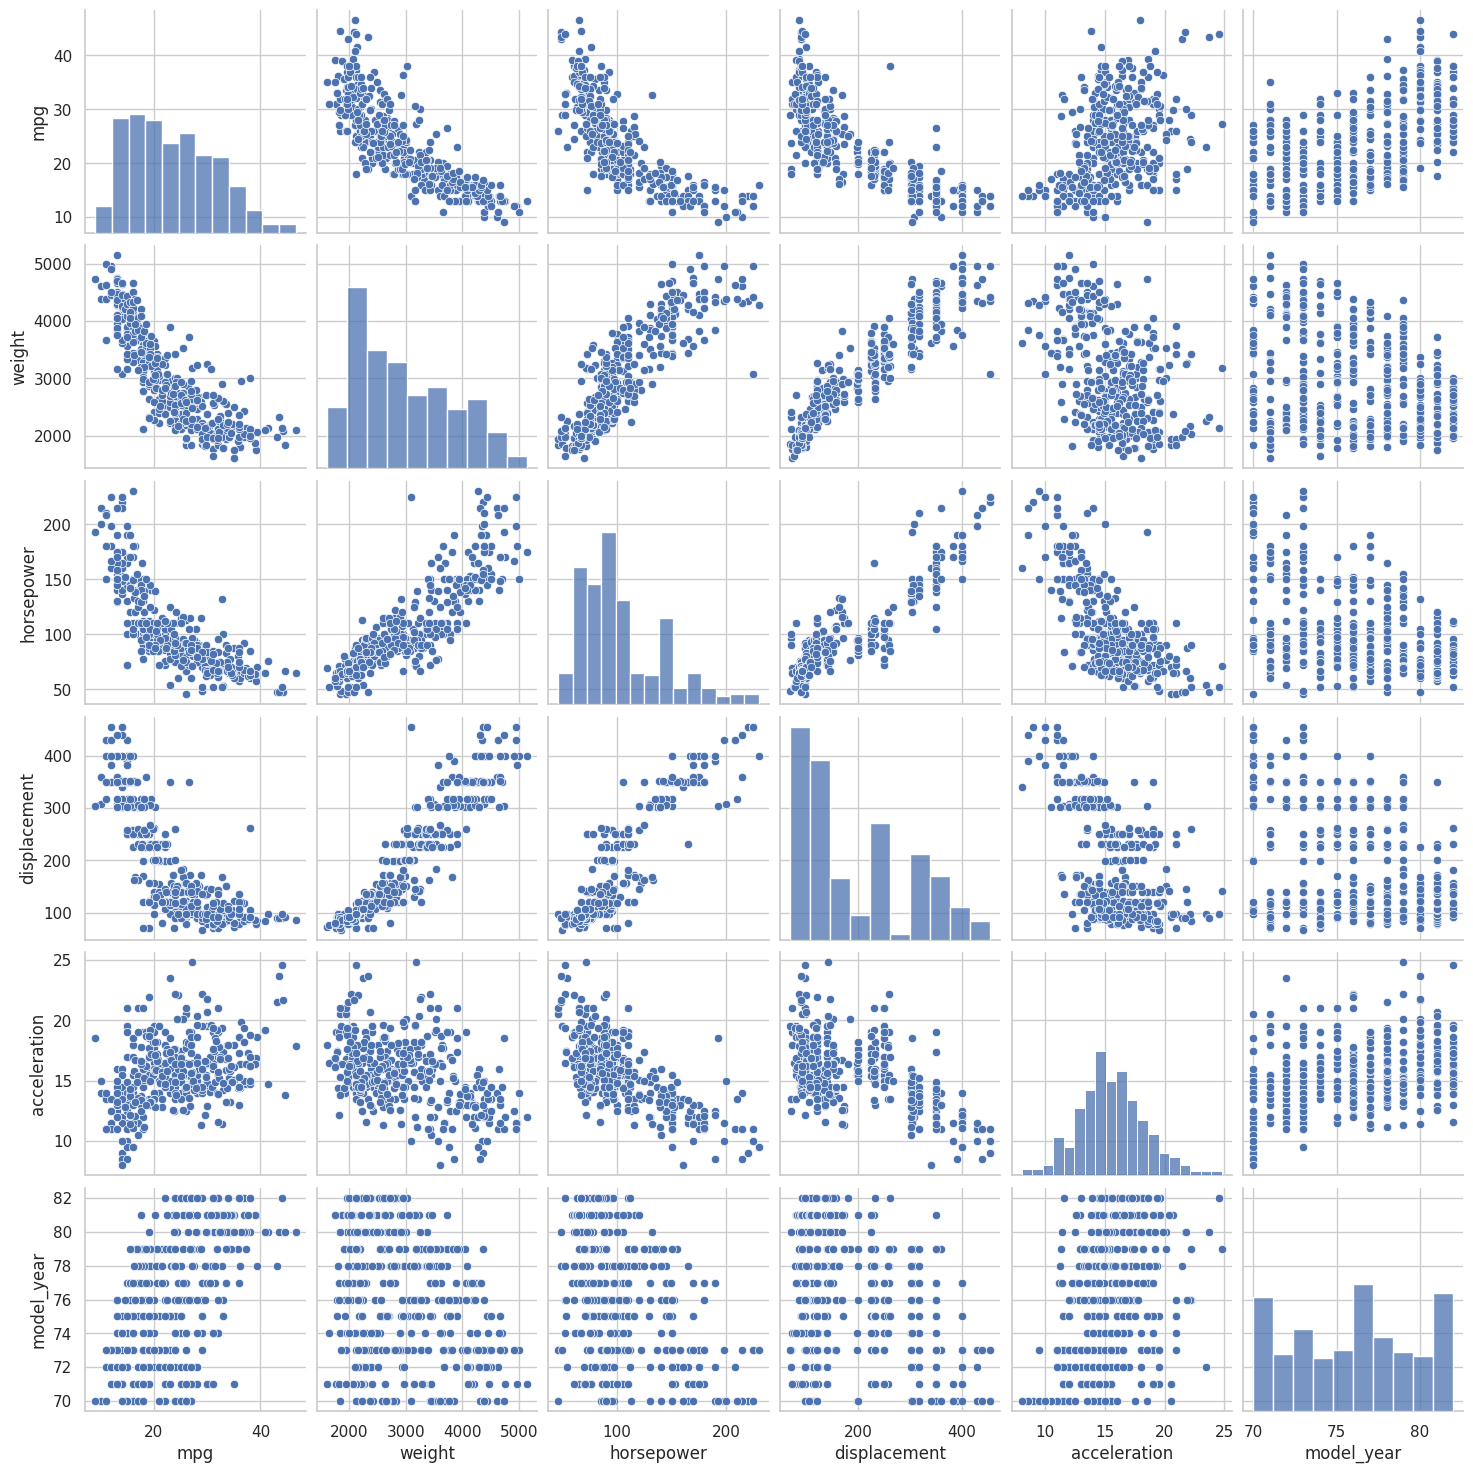

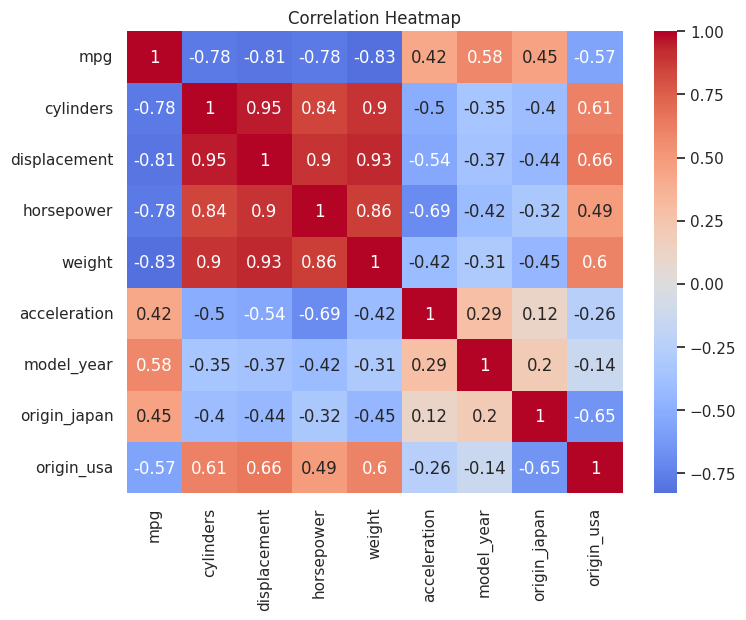

In [3]:
sns.pairplot(df[['mpg','weight','horsepower','displacement','acceleration','model_year']])
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

## 2. Fit Base Linear Regression Model

In [4]:
df = df.drop(columns=['name'])

X = df.drop(columns=['mpg'])
y = df['mpg']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)
residuals = y - y_pred

## 3. Check Each Assumption Visually

### 1️⃣ Linearity

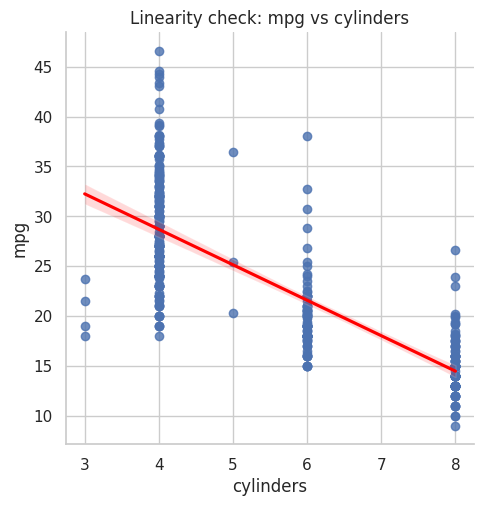

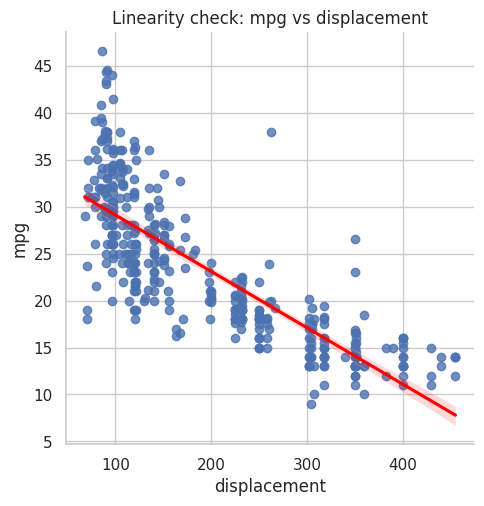

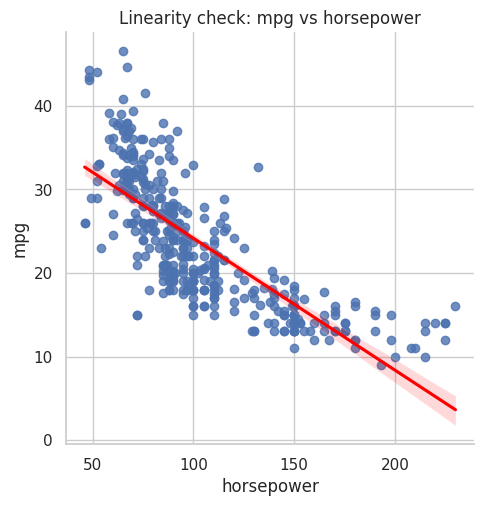

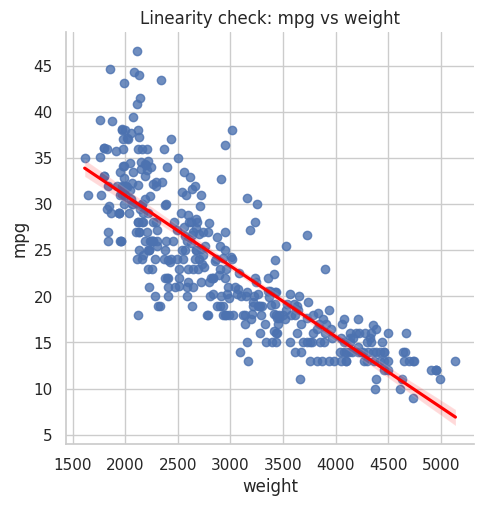

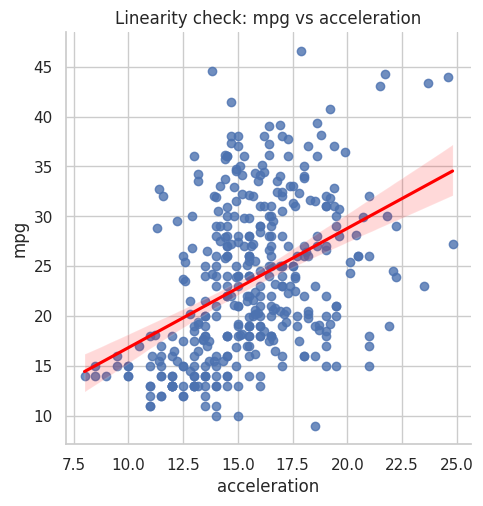

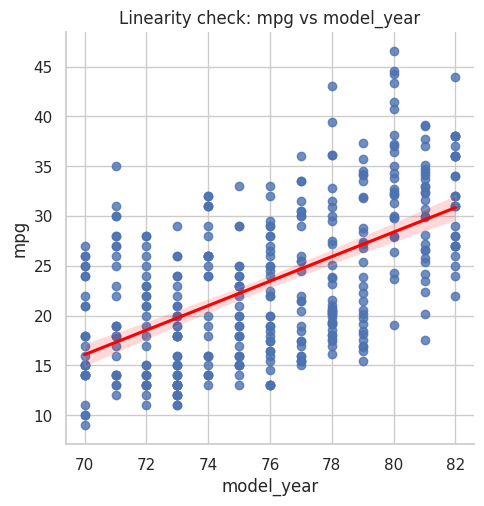

In [5]:
for col in X.columns[:6]:  # numeric predictors
    sns.lmplot(x=col, y='mpg', data=df, line_kws={'color':'red'})
    plt.title(f'Linearity check: mpg vs {col}')
    plt.show()
# Observation: Curved patterns for weight, displacement, horsepower indicate nonlinearity.

### 2️⃣ Mean of Residuals = 0

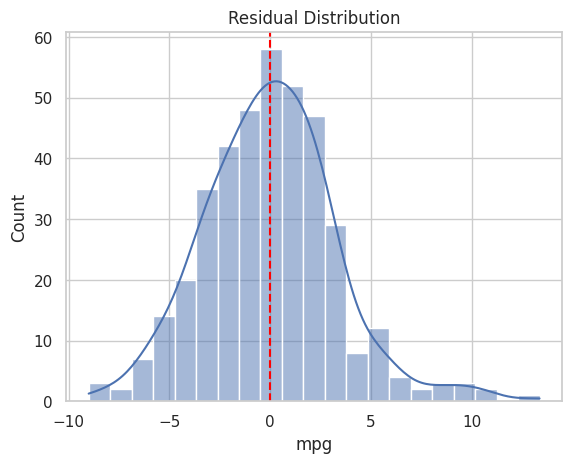

Mean of residuals: -2.3201395453391025e-15


In [6]:
sns.histplot(residuals, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title("Residual Distribution")
plt.show()
print("Mean of residuals:", residuals.mean())
# Observation: Centered around zero.

### 3️⃣ Homoscedasticity (Equal Variance)

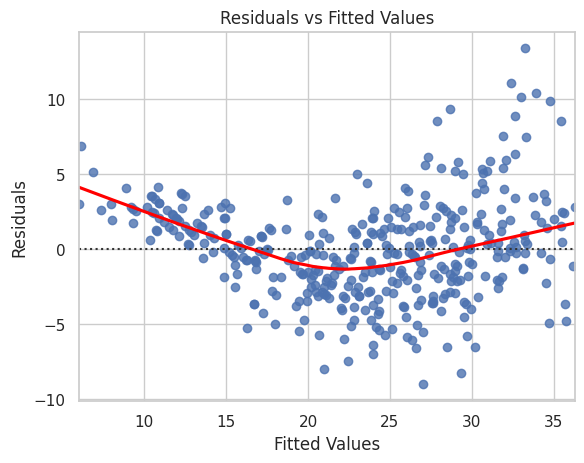

In [7]:
sns.residplot(x=y_pred, y=residuals, lowess=True, line_kws={'color':'red'})
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()
# Observation: Funnel pattern → heteroscedasticity present.

### 4️⃣ Normality of Residuals

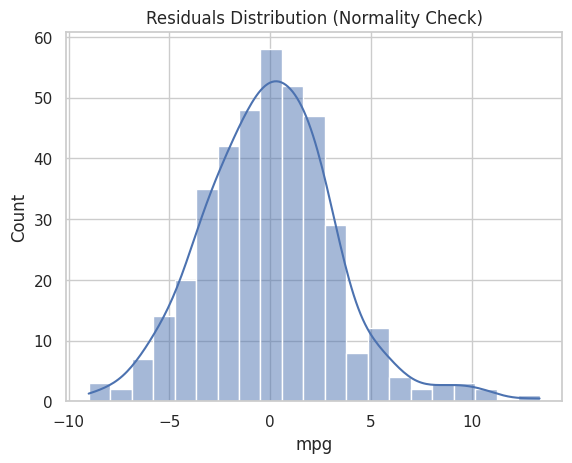

In [8]:
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution (Normality Check)")
plt.show()
# Observation: Right-skewed residuals → not perfectly normal.

### 5️⃣ No Autocorrelation

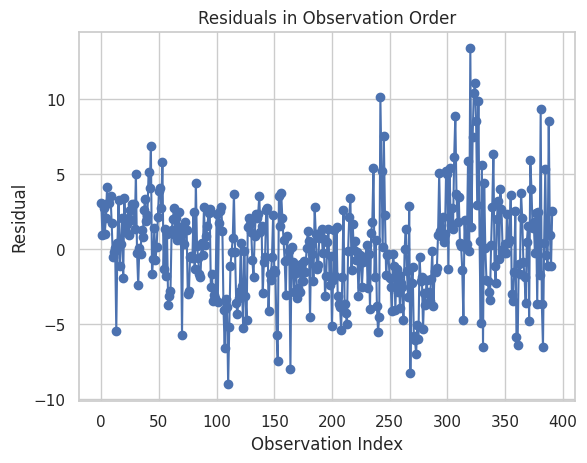

In [9]:
plt.plot(residuals.values, marker='o')
plt.title("Residuals in Observation Order")
plt.xlabel("Observation Index")
plt.ylabel("Residual")
plt.show()
# Observation: No visible pattern → likely uncorrelated.

### 6️⃣ No Multicollinearity

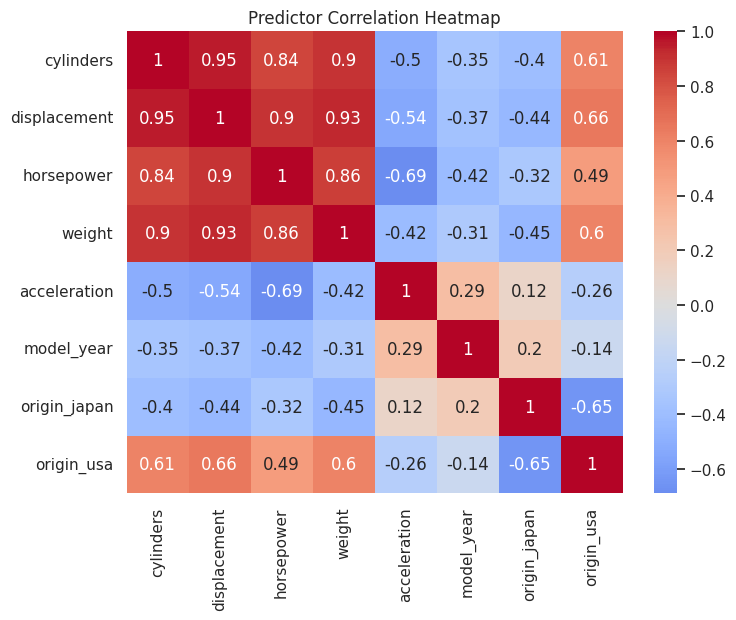

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(X.corr(numeric_only=True), annot=True, cmap='coolwarm', center=0)
plt.title("Predictor Correlation Heatmap")
plt.show()
# Observation: Strong correlation between weight, displacement, horsepower → multicollinearity risk.

### ⚡ Beyond the syllabus — the four residual-plot shapes — the whole diagnosis in one picture

Almost every regression problem announces itself in the residuals-vs-fitted plot, and there are only four shapes worth recognising. Learn these and you can diagnose a model from a single chart in about three seconds — which is exactly what an exam question showing you a plot is testing.

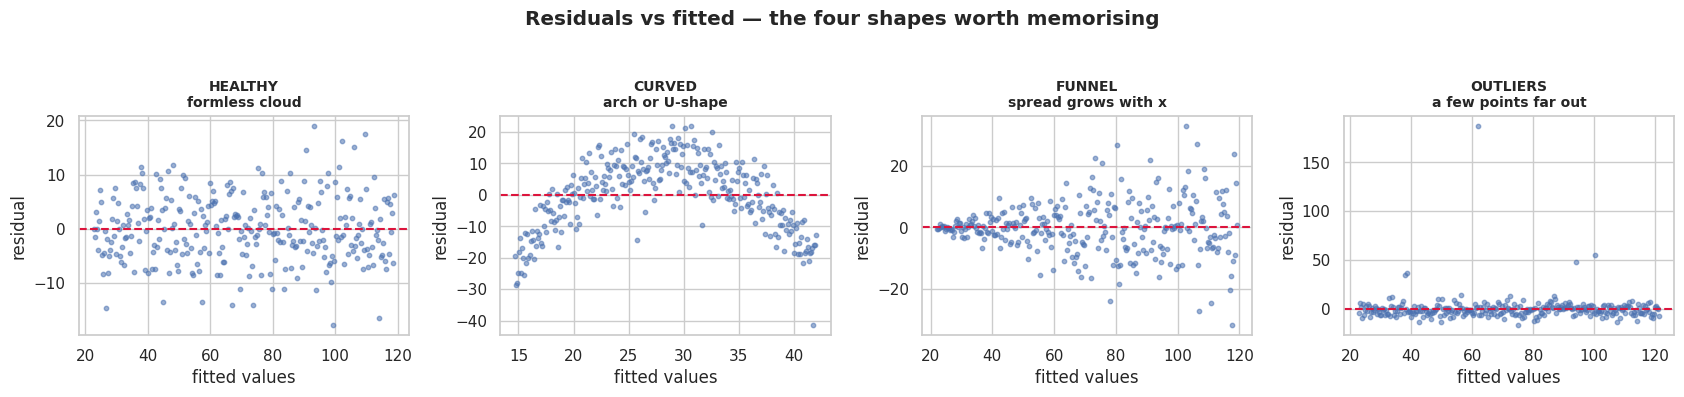

HEALTHY — formless cloud           Nothing wrong. No pattern, even spread, centred on zero.
CURVED — arch or U-shape           LINEARITY violated -> add a squared term or transform x.
FUNNEL — spread grows with x       HOMOSCEDASTICITY violated -> transform y, or use HC3 robust SEs.
OUTLIERS — a few points far out    NORMALITY / influence -> investigate those rows before deciding.

HOW TO PHRASE IT IN AN ANSWER
  "The residuals-vs-fitted plot shows a clear funnel widening with the fitted values,
   indicating heteroscedasticity. The coefficient estimates remain unbiased, but the
   standard errors are understated, so I report HC3 robust standard errors instead of
   the default ones."
That sentence names the shape, names the assumption, states the consequence, and gives
the fix. Four marks in one sentence.


In [11]:
rng = np.random.default_rng(0)
n = 300
x = np.linspace(1, 50, n)

shapes = {
    'HEALTHY\nformless cloud':          (x, 20 + 2*x + rng.normal(0, 6, n)),
    'CURVED\narch or U-shape':          (x, 20 + 2*x - 0.05*x**2 + rng.normal(0, 6, n)),
    'FUNNEL\nspread grows with x':      (x, 20 + 2*x + rng.normal(0, 1, n) * x * 0.35),
    'OUTLIERS\na few points far out':   (x, 20 + 2*x + rng.normal(0, 5, n) +
                                          np.where(rng.random(n) < .02, rng.normal(0, 70, n), 0)),
}
diagnosis = {
    'HEALTHY\nformless cloud':        'Nothing wrong. No pattern, even spread, centred on zero.',
    'CURVED\narch or U-shape':        'LINEARITY violated -> add a squared term or transform x.',
    'FUNNEL\nspread grows with x':    'HOMOSCEDASTICITY violated -> transform y, or use HC3 robust SEs.',
    'OUTLIERS\na few points far out': 'NORMALITY / influence -> investigate those rows before deciding.',
}

fig, axes = plt.subplots(1, 4, figsize=(17, 3.8))
for ax, (title, (xs, ys)) in zip(axes, shapes.items()):
    fitted = np.polyval(np.polyfit(xs, ys, 1), xs)
    ax.scatter(fitted, ys - fitted, s=10, alpha=.55)
    ax.axhline(0, color='crimson', ls='--', lw=1.5)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('fitted values'); ax.set_ylabel('residual')
plt.suptitle('Residuals vs fitted — the four shapes worth memorising', fontweight='bold', y=1.04)
plt.tight_layout(); plt.show()

for title, verdict in diagnosis.items():
    print(f"{title.replace(chr(10), ' — '):<34} {verdict}")

print("""
HOW TO PHRASE IT IN AN ANSWER
  "The residuals-vs-fitted plot shows a clear funnel widening with the fitted values,
   indicating heteroscedasticity. The coefficient estimates remain unbiased, but the
   standard errors are understated, so I report HC3 robust standard errors instead of
   the default ones."
That sentence names the shape, names the assumption, states the consequence, and gives
the fix. Four marks in one sentence.""")

---

## Exam quick-reference

| To do this | Write this |
|---|---|
| All pairs at once | `sns.pairplot(df[cols])` |
| Correlation heatmap | `sns.heatmap(df.corr(numeric_only=True), annot=True)` |
| Scatter with fit | `sns.lmplot(x=, y=, data=)` |
| Residual plot | `sns.residplot(x=fitted, y=resid)` |
| Residual histogram | `sns.histplot(resid, kde=True)` |
| Q-Q plot | `qqplot(resid, line='s')` |
| Residuals in order | `plt.plot(resid)` (autocorrelation) |
| Dummy variables | `pd.get_dummies(df, columns=['origin'], drop_first=True)` |

### Adapting this in the exam

- Shown a residual plot and asked what's wrong? Match it to one of the four shapes and name the assumption.
- 'Check the assumptions visually' → one plot per assumption, one sentence of interpretation under each.
- Always state the consequence, not just the diagnosis — that's where the second mark is.

### Traps that cost marks

- A residual **histogram** checks normality; a residual **scatter** checks linearity and equal spread. They answer different questions.
- `sns.pairplot` on many columns is very slow — pass a shortlist.
- `df.corr()` needs `numeric_only=True` when text columns are present.
- Visual checks are subjective. In a written answer, back the picture with a named test.
- A Q-Q plot with points bending away at both ends means heavy tails, not skew.